# EnergyLens-AI - Notebook 5: Anomaly Detection & Clustering

This notebook moves away from forecasting into unsupervised learning. Two goals here:
1. Anomaly detection - flag days where a household's consumption looks unusual (could be an appliance issue, an empty house, or just an extreme demand spike).
2. Household clustering - group households into usage archetypes based on how they consume energy.

With 3.5 million daily rows, clustering directly on all of them isn't really feasible (something like DBSCAN gets very slow at that scale). So instead I built one profile vector per household (5,566 of them) with stats like:
- Average daily consumption and how much it varies
- Thermal sensitivity - ratio of winter to summer consumption
- Weekend bias - ratio of weekend to weekday consumption

Clustering on 5,566 profile rows instead of 3.5 million daily rows runs in seconds and is also more meaningful, since it describes the household rather than a single day.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 6)

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"✅ Setup complete. Running in Colab: {IN_COLAB}")


✅ Setup complete. Running in Colab: True


## 2. Load Data

Loading the feature matrix from Notebook 3.


In [2]:
if IN_COLAB:
    from google.colab import files
    print("📤 Please upload master_features.parquet")
    uploaded = files.upload()
    features_path = list(uploaded.keys())[0]
else:
    features_path = '../data/processed/master_features.parquet'
    if not os.path.exists(features_path):
        raise FileNotFoundError(f"Missing feature matrix: {features_path}. Please run Notebook 3 first.")

# Load the dataset
print("Loading feature matrix...")
df = pd.read_parquet(features_path)
print(f"Dataset shape: {df.shape}")


📤 Please upload master_features.parquet


Saving master_features.parquet to master_features.parquet
Loading feature matrix...
Dataset shape: (3332960, 58)


## 3. Anomaly Detection

Comparing a simple statistical method (rolling Z-score) against a machine learning method (Isolation Forest).

I used a single household to visualize this clearly instead of trying to plot all of them at once.


In [3]:
# Extract a single household for visualization
sample_household = df['LCLid'].iloc[0]
hh_df = df[df['LCLid'] == sample_household].sort_values('day').reset_index(drop=True)
print(f"Selected household: {sample_household} ({len(hh_df)} records)")

# Method A: Rolling Z-score
# Flag days more than 3 std away from the 7-day rolling mean
hh_df['z_score'] = (hh_df['energy_mean'] - hh_df['energy_roll_mean_7']) / (hh_df['energy_roll_std_7'] + 1e-5)
hh_df['anomaly_z'] = (np.abs(hh_df['z_score']) > 3.0).astype(int)

print(f"Rolling Z-Score flagged {hh_df['anomaly_z'].sum()} anomalies.")


Selected household: MAC000002 (473 records)
Rolling Z-Score flagged 30 anomalies.


In [4]:
# Method B: Isolation Forest
# Features used for Isolation Forest
features_for_anomaly = ['energy_mean', 'energy_std', 'temp_avg', 'is_weekend']
iso_forest = IsolationForest(contamination=0.02, random_state=42) # Assume 2% of days are anomalies

# Fit and predict (1 = normal, -1 = anomaly)
hh_df['anomaly_if'] = iso_forest.fit_predict(hh_df[features_for_anomaly])
hh_df['anomaly_if'] = (hh_df['anomaly_if'] == -1).astype(int)

print(f"Isolation Forest flagged {hh_df['anomaly_if'].sum()} anomalies.")


Isolation Forest flagged 10 anomalies.


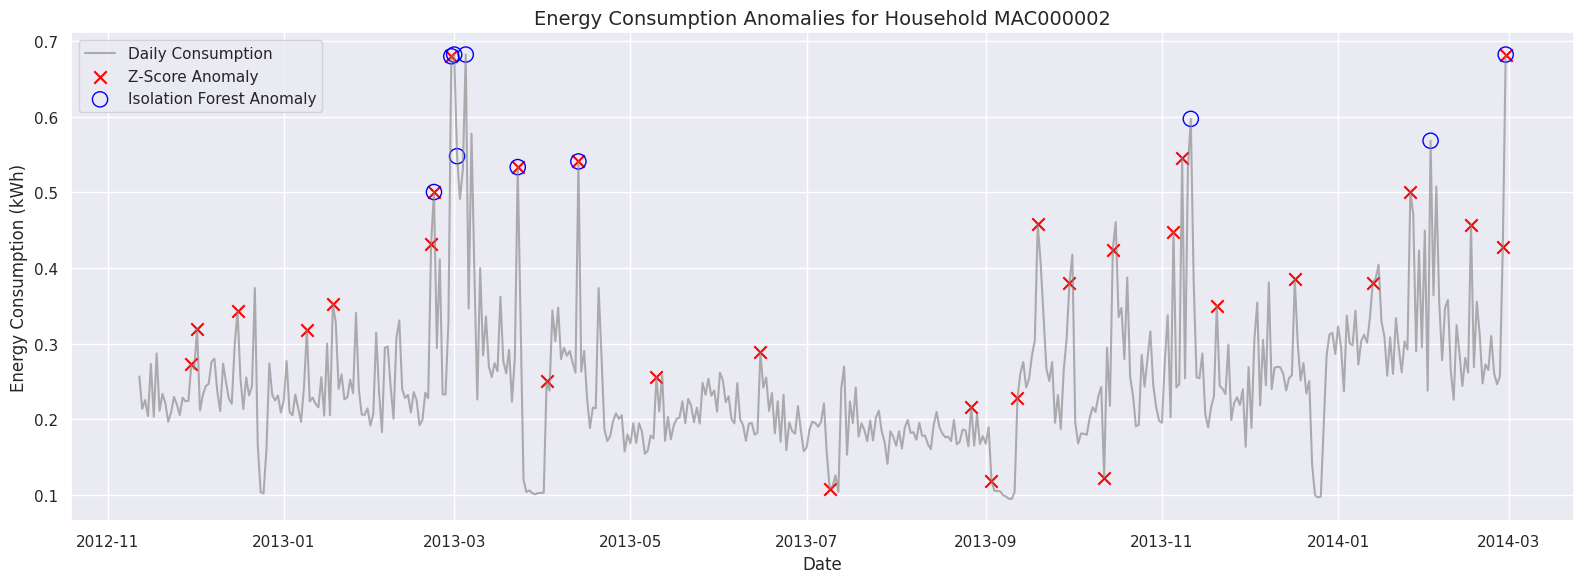

In [5]:
# Compare both methods visually
plt.figure(figsize=(16, 6))
plt.plot(hh_df['day'], hh_df['energy_mean'], label='Daily Consumption', color='gray', alpha=0.6)

# Overlay Z-Score anomalies
z_anom = hh_df[hh_df['anomaly_z'] == 1]
plt.scatter(z_anom['day'], z_anom['energy_mean'], color='red', label='Z-Score Anomaly', marker='x', s=80)

# Overlay Isolation Forest anomalies
if_anom = hh_df[hh_df['anomaly_if'] == 1]
plt.scatter(if_anom['day'], if_anom['energy_mean'], color='blue', label='Isolation Forest Anomaly', facecolors='none', edgecolors='blue', s=120)

plt.title(f'Energy Consumption Anomalies for Household {sample_household}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Household Profile Engineering (for Clustering)

Aggregating the 3.5 million daily rows into one profile vector per household.

I originally tried a `groupby.agg` with custom lambda functions for the seasonal/weekend means, but that was quite slow on 3.3+ million rows. Using `.where()` to create masked temporary columns first and then aggregating with plain vectorized `.mean()` calls was a lot faster (a few seconds instead of a few minutes).


In [6]:
print("Engineering household-level profile features...")

# Temporary columns for seasonal/weekend means
df['winter_consumption'] = df['energy_mean'].where(df['month'].isin([12, 1, 2]))
df['summer_consumption'] = df['energy_mean'].where(df['month'].isin([6, 7, 8]))
df['weekend_consumption'] = df['energy_mean'].where(df['is_weekend'] == 1)
df['weekday_consumption'] = df['energy_mean'].where(df['is_weekend'] == 0)

# Aggregate down to one row per household
profiles = df.groupby('LCLid').agg(
    mean_daily_consumption=('energy_mean', 'mean'),
    std_consumption=('energy_mean', 'std'),
    winter_mean=('winter_consumption', 'mean'),
    summer_mean=('summer_consumption', 'mean'),
    weekend_mean=('weekend_consumption', 'mean'),
    weekday_mean=('weekday_consumption', 'mean'),
    tariff_code=('tariff_code', 'first'),
    acorn_code=('acorn_code', 'first'),
    total_days=('energy_mean', 'count')
).reset_index()

# Clean up temporary columns in df to free RAM
df = df.drop(columns=['winter_consumption', 'summer_consumption', 'weekend_consumption', 'weekday_consumption'])

# Drop households with less than 100 days of history - not enough to get a reliable seasonal profile
profiles = profiles[profiles['total_days'] >= 100]
profiles = profiles.dropna(subset=['winter_mean', 'summer_mean'])

# Thermal sensitivity ratio, capped at 5.0 to handle extreme outliers
profiles['thermal_sensitivity'] = profiles['winter_mean'] / (profiles['summer_mean'] + 1e-5)
profiles['thermal_sensitivity'] = np.minimum(profiles['thermal_sensitivity'], 5.0)

profiles['weekend_bias'] = profiles['weekend_mean'] / (profiles['weekday_mean'] + 1e-5)

# Drop any remaining NaNs
profiles = profiles.dropna()
print(f"Generated profile vectors for {profiles.shape[0]} households.")
profiles.head(3)


Engineering household-level profile features...
Generated profile vectors for 5530 households.


,LCLid,mean_daily_consumption,std_consumption,winter_mean,summer_mean,weekend_mean,weekday_mean,tariff_code,acorn_code,total_days,thermal_sensitivity,weekend_bias
0,MAC000002,0.250930,0.093763,0.278786,0.190438,0.264013,0.245812,0.0,1.0,473,1.463844,1.073999
1,MAC000003,0.394902,0.243866,0.586285,0.254774,0.391343,0.396303,0.0,16.0,708,2.301101,0.987460
2,MAC000004,0.035402,0.007617,0.038483,0.031703,0.035862,0.035220,0.0,5.0,630,1.213495,1.017952


## 5. Finding K (Elbow Method)

Before picking K, I scaled the profile features. First time I ran KMeans on the raw profile features, one cluster ended up with just a single household in it. Turned out an extreme thermal sensitivity value for that household was pulling KMeans off balance, so I capped extreme values (1st/99th percentile) on the clustering features before scaling and re-ran it.


✅ Extreme profile values capped before clustering
       mean_daily_consumption  std_consumption  thermal_sensitivity  \
count             5530.000000      5530.000000          5530.000000   
mean                 0.209887         0.077710             1.471000   
std                  0.139475         0.071688             0.701413   
min                  0.030818         0.009396             0.613132   
25%                  0.111985         0.033505             1.110645   
50%                  0.173691         0.055528             1.279221   
75%                  0.266620         0.091836             1.536882   
max                  0.776328         0.416637             5.000000   

       weekend_bias  
count   5530.000000  
mean       1.053875  
std        0.124481  
min        0.687701  
25%        0.988089  
50%        1.038726  
75%        1.113602  
max        1.478949  


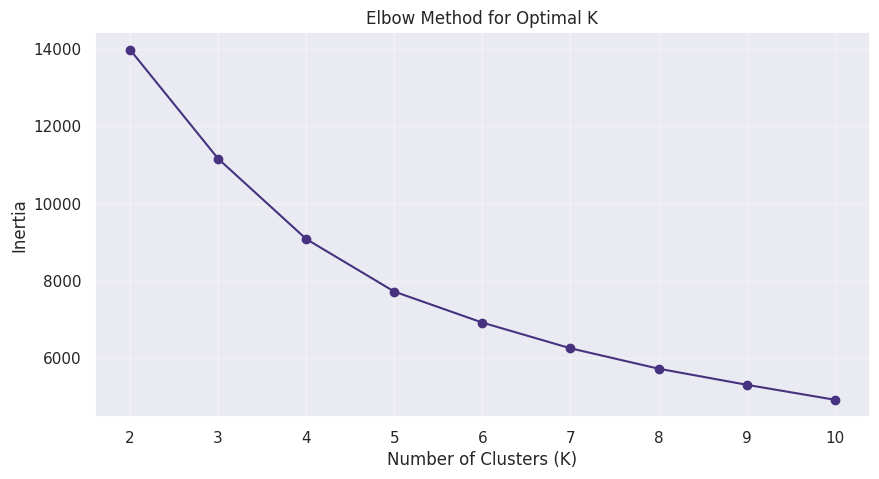

In [7]:
# Select clustering features
cluster_features = [
    'mean_daily_consumption',
    'std_consumption',
    'thermal_sensitivity',
    'weekend_bias'
]

# Copy profiles so the original engineered values remain unchanged
profiles_clean = profiles.copy()

# Cap extreme values at the 1st and 99th percentiles
for col in cluster_features:
    lower = profiles_clean[col].quantile(0.01)
    upper = profiles_clean[col].quantile(0.99)
    profiles_clean[col] = profiles_clean[col].clip(lower=lower, upper=upper)

print('✅ Extreme profile values capped before clustering')
print(profiles_clean[cluster_features].describe())

# Scale the cleaned features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(profiles_clean[cluster_features])

# Elbow method
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.show()

The elbow bends around K = 3 or K = 4. I went with K = 3 to keep the household archetypes distinct and easy to interpret.


In [8]:
# Fit KMeans on cleaned and scaled household profiles
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
profiles_clean['cluster'] = kmeans.fit_predict(scaled_features)

print('✅ KMeans clustering completed.')
print('\nCluster sizes:')
print(profiles_clean['cluster'].value_counts().sort_index())

✅ KMeans clustering completed.

Cluster sizes:
cluster
0     653
1    3294
2    1583
Name: count, dtype: int64


## 6. Profiling the Clusters

Checking the average feature values per cluster to see what each group actually represents.


In [9]:
cluster_summary = (
    profiles_clean.groupby('cluster')[cluster_features]
    .mean()
    .reset_index()
)

print('🏆 Cluster Archetype Statistics:')
display(cluster_summary)

print('\nCluster sizes:')
display(profiles_clean['cluster'].value_counts().sort_index())

🏆 Cluster Archetype Statistics:


,cluster,mean_daily_consumption,std_consumption,thermal_sensitivity,weekend_bias
0,0,0.456227,0.231990,2.691856,1.011288
1,1,0.158798,0.050276,1.294184,0.996271
2,2,0.214578,0.071154,1.335316,1.191309



Cluster sizes:


,count
cluster,
0,653
1,3294
2,1583


Looking at the cluster averages:
- Cluster 0 - low consumption, low volatility, low weather sensitivity. Looks like smaller or more energy-conscious households.
- Cluster 1 - high consumption, high volatility, high thermal sensitivity. Likely bigger houses, possibly using electric heating.
- Cluster 2 - average consumption and moderate weather sensitivity, somewhere in between.


In [10]:
# Save household cluster profiles
output_dir = '/content/processed' if IN_COLAB else '../data/processed'
os.makedirs(output_dir, exist_ok=True)

profiles_out_path = os.path.join(output_dir, 'household_profiles.csv')

profiles_clean[
    ['LCLid', 'cluster'] + cluster_features
].to_csv(profiles_out_path, index=False)

print(f'✅ Saved household cluster profiles to: {profiles_out_path}')

✅ Saved household cluster profiles to: /content/processed/household_profiles.csv


## 7. Cluster Visualization (PCA)

The clustering features are 4-dimensional, so I used PCA to project down to 2D just to visualize how separated the clusters are.


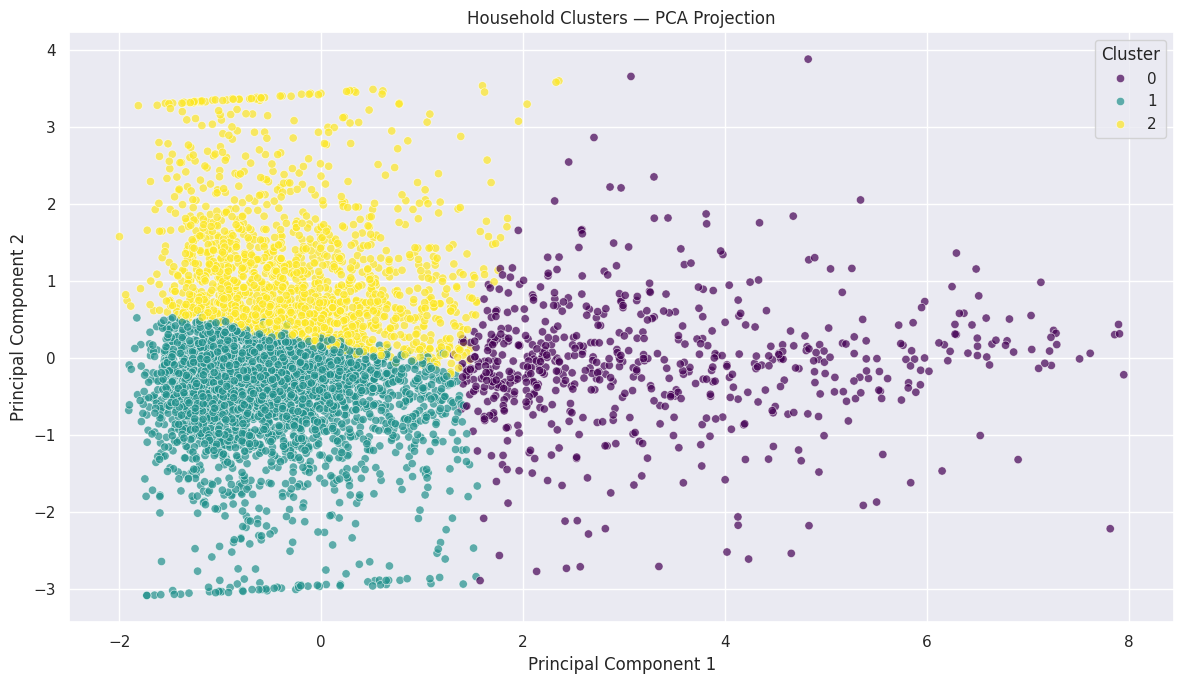

Explained variance ratio: [0.55359735 0.24813132]
Total explained variance: 0.8017286749457865


In [11]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_features)

profiles_clean['pca_1'] = pca_features[:, 0]
profiles_clean['pca_2'] = pca_features[:, 1]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=profiles_clean,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='viridis',
    alpha=0.7
)
plt.title('Household Clusters — PCA Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

## 8. Notes

Z-score is fast but only looks at one variable at a time, so it can miss things - a household using 1 kWh on a freezing day might look "normal" by Z-score alone, but Isolation Forest can catch it since it looks at multiple features together (energy, temperature, weekend flag) and would flag that combination as unusual.

I also clustered on the household profile stats rather than raw daily rows on purpose. If I clustered raw daily values, the same household could land in different clusters depending on the season, which isn't really useful for segmenting customers. The profile features (thermal sensitivity, weekend bias, average consumption) act more like a fixed fingerprint per household.

### Next (Notebook 6)
In the final notebook I bring this together - the XGBoost forecaster, the cluster assignments, and anomaly detection - into one pipeline that also gives some basic personalized recommendations.
